타이타닉 + IMDB
##  matplotlib
나이 히스토그램

성별 생존자 막대

나이 vs 요금 산점도

등급별 요금 박스플롯

탑승항 파이차트

## plotly
IMDB 평점 histogram

투표 수 vs 평점 scatter

HTML 저장

In [13]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')    # Windows 내장
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')      # macOS
else:
    plt.rc('font', family='NanumGothic')      # Ubuntu: sudo apt install fonts-nanum

plt.rc('axes', unicode_minus=False)           # 마이너스 기호 깨짐 방지

In [7]:
import pandas as pd


TITANIC_URL = (
  'https://raw.githubusercontent.com/'
  'datasciencedojo/datasets/master/titanic.csv'
)
titanic = pd.read_csv(TITANIC_URL)
titanic.shape   # (891, 12)

(891, 12)

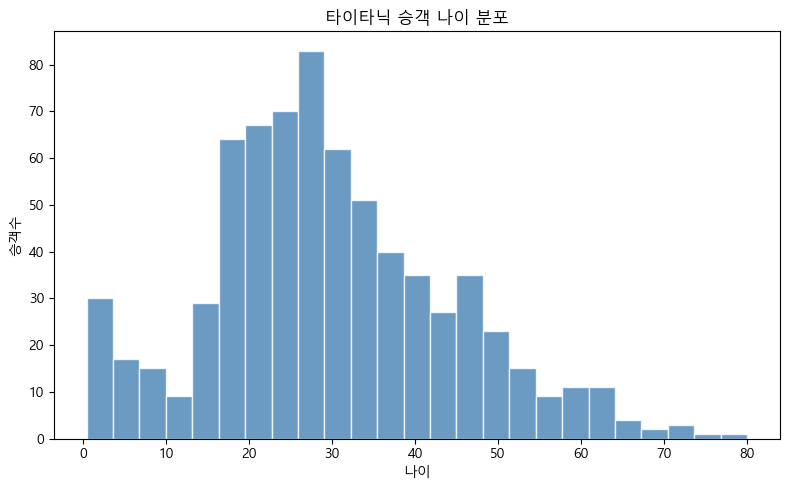

In [14]:
fig, ax = plt.subplots(figsize =(8,5))
ax.hist(titanic['Age'],
        bins = 25,
        color = 'steelblue',
        edgecolor = 'white',
        alpha = 0.8
        )
ax.set_xlabel('나이')
ax.set_ylabel('승객수')
ax.set_title("타이타닉 승객 나이 분포")
plt.tight_layout()
plt.show()

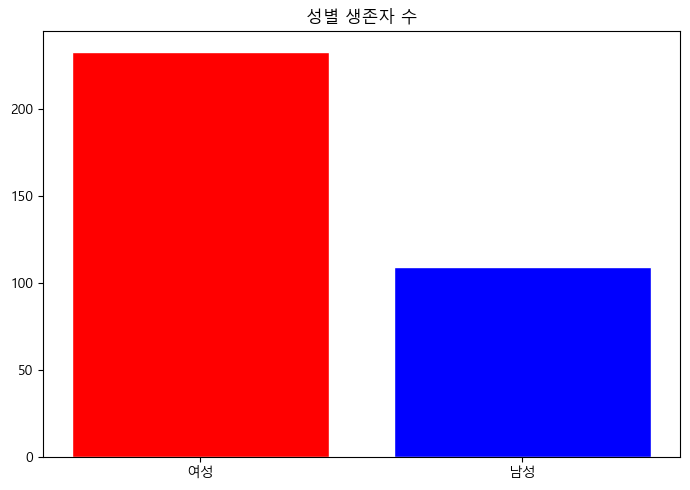

In [21]:
surv_class = titanic.groupby('Sex')['Survived'].sum()

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(surv_class.index, surv_class.values,
       color=['red','blue'],
       edgecolor='white')
ax.set_title("성별 생존자 수")
ax.set_xticks([0,1])
ax.set_xticklabels(['여성','남성'])
plt.tight_layout();
plt.show()

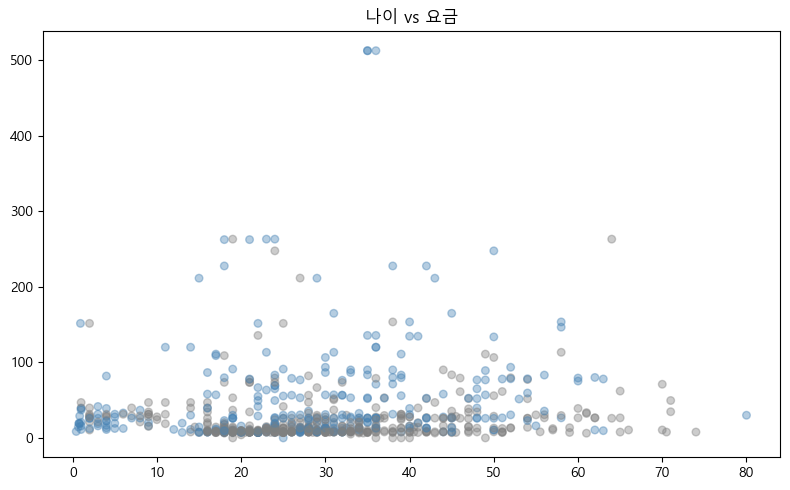

In [23]:
colors = titanic['Survived'].map(
    {0: 'gray', 1: 'steelblue'}
)

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(
    titanic['Age'],
    titanic['Fare'],
    c=colors, alpha=0.4, s = 30
)
ax.set_title('나이 vs 요금')
plt.tight_layout();
plt.show()


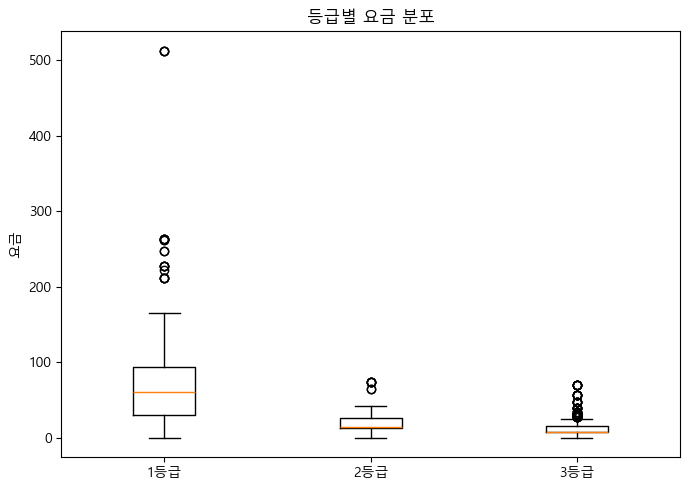

In [25]:
data = [titanic[titanic['Pclass'] ==c]['Fare'].dropna()
                        for c in [1,2,3]]
fig, ax = plt.subplots(figsize=(7,5))
ax.boxplot(data,
           tick_labels=['1등급', '2등급', '3등급'])
ax.set_ylabel('요금')
ax.set_title('등급별 요금 분포')
plt.tight_layout()
plt.show()

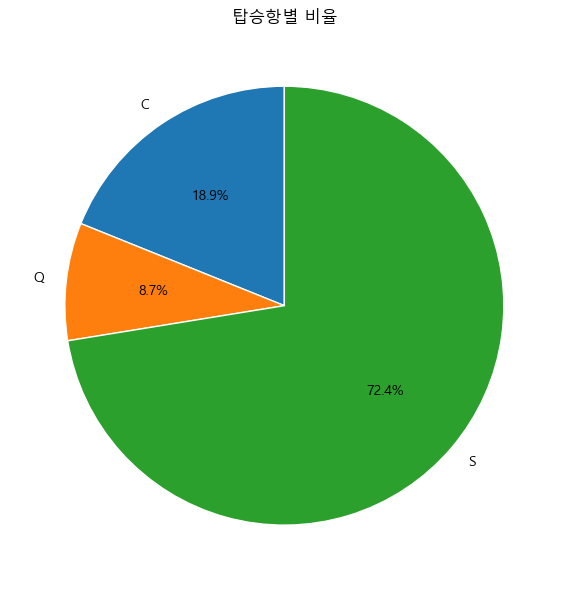

In [43]:
embarkeds = titanic['Embarked'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(embarkeds.values,
       labels=['C','Q','S'],
       autopct='%1.1f%%',
       startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('탑승항별 비율')
plt.tight_layout(); plt.show()

In [55]:
import plotly.express as px
imdb = pd.read_csv('imdb_top_1000.csv')
imdb.shape    # (1000, 16)


(1000, 16)

In [56]:
fig = px.histogram(
    imdb,
    x='IMDB_Rating',
    nbins=20,
    marginal='box',
    title='IMDB 평점 분포',
    template='simple_white'
)
fig.show()

In [58]:
fig = px.scatter(
    imdb,
    x = 'No_of_Votes',
    y = 'IMDB_Rating',
    hover_name= 'Series_Title',
    hover_data= ['Released_Year', 'Genre'],
    title = '투표 수 vs IMDB 평점',
    template= 'simple_white',
    opacity=0.6 
)
fig.show()
fig.write_html('imbd_scatter.html')